Take these two algorithms, PSO and ABC. Propose a modification to the basic algorithm. The modification must be a significant change to the behavior of the algorithm. A simple randomization or change in parameter values is not considered significant.

Compare the performance of these algorithms and their modificaiton on the following functions:
a.	Rastrigin Function
b.	Styblinski-Tang Function

In [35]:
import numpy as np
import random
import math

In [36]:
def Rastrigin_function(x):
    """Global minimum at x = (0, 0, ..., 0) with f(x) = 0."""
    return 10 * len(x) + sum([(xi - 1) ** 2 - 10 * math.cos(2 * math.pi * (xi - 1)) for xi in x])
 
def Styblinski_Tang_function(x):
    """Global minimum at x = (-2.903534, -2.903534) with f(x) = -39.16617."""
    return 0.5 * sum([xi ** 4 - 16 * xi ** 2 + 5 * xi for xi in x])


In [37]:
# PSO parameters
MAX_VELOCITY = 1.0  # Maximum velocity for particles
BOUNDS = [-5, 5]    # Search space bounds for x and y

class Particle:
    """Represents a single particle in the PSO swarm."""
    
    def __init__(self, position):
        """
        Initialize a particle with random velocity.
        
        Args:
            position: List of coordinates for the particle
        """
        self.position = position.copy() if isinstance(position, list) else list(position)
        self.velocity = [random.uniform(-MAX_VELOCITY, MAX_VELOCITY) for _ in range(len(position))]
        self.p_best = self.position.copy()  # Best position found by this particle
        self.p_best_fitness = self.fitness()  # Fitness of the best position
 
    def fitness(self):
        """Calculate the fitness (objective function value) of current position."""
        return Rastrigin_function(self.position)
 
    def update(self, g_best, c1=1.0, c2=1.0, w=0.7):
        """
        Update particle velocity and position.
        
        Args:
            g_best: Global best position (list of coordinates)
            c1: Cognitive parameter (default: 1.0)
            c2: Social parameter (default: 1.0)
            w: Inertia weight (default: 0.7)
        """
        for i in range(len(self.position)):
            r1 = random.random()
            r2 = random.random()
            
            # Update velocity: v = w*v + c1*r1*(pbest - x) + c2*r2*(gbest - x)
            self.velocity[i] = (
                w * self.velocity[i] +
                c1 * r1 * (self.p_best[i] - self.position[i]) +
                c2 * r2 * (g_best[i] - self.position[i])
            )
            
            # Limit velocity to avoid explosion
            self.velocity[i] = np.clip(self.velocity[i], -MAX_VELOCITY, MAX_VELOCITY)
 
            # Update position
            self.position[i] += self.velocity[i]
 
            # Constrain position to search space bounds
            self.position[i] = np.clip(self.position[i], BOUNDS[0], BOUNDS[1])
 
        # Update personal best if current position is better
        current_fitness = self.fitness()
        if current_fitness < self.p_best_fitness:
            self.p_best = self.position.copy()
            self.p_best_fitness = current_fitness
 
 
class ModifiedParticle(Particle):
    """Enhanced particle with stagnation detection and reinitialization."""
    
    def __init__(self, position, stagnation_limit=5):
        """
        Initialize a modified particle.
        
        Args:
            position: List of coordinates
            stagnation_limit: Number of iterations without improvement before reinitializing
        """
        super().__init__(position)
        self.stagnation = 0
        self.stagnation_limit = stagnation_limit
 
    def update(self, g_best, c1=1.0, c2=1.0, w=0.7):
        """
        Update particle with stagnation detection.
        
        Args:
            g_best: Global best position
            c1: Cognitive parameter
            c2: Social parameter
            w: Inertia weight
        """
        prev_best = self.p_best_fitness
        super().update(g_best, c1, c2, w)
 
        # Track stagnation
        if self.p_best_fitness < prev_best:
            self.stagnation = 0
        else:
            self.stagnation += 1
 
        # Reinitialize if stagnated too long
        if self.stagnation > self.stagnation_limit:
            self.reinitialize()
 
    def reinitialize(self):
        """Reinitialize particle with new random position and velocity."""
        self.position = [random.uniform(BOUNDS[0], BOUNDS[1]) for _ in range(2)]
        self.velocity = [random.uniform(-MAX_VELOCITY, MAX_VELOCITY) for _ in range(2)]
        self.p_best = self.position.copy()
        self.p_best_fitness = self.fitness()
        self.stagnation = 0
 
 
class Swarm:
    """PSO Swarm implementation."""
    
    def __init__(self, num_particles, objective_fn, is_minimization=True):
        """
        Initialize the swarm.
        
        Args:
            num_particles: Number of particles in the swarm
            objective_fn: Objective function to optimize
            is_minimization: True if minimizing, False if maximizing
        """
        self.swarm = []
        self.objective_fn = objective_fn
        self.is_minimization = is_minimization
        self.g_best = None  # Initialize global best
        self.g_best_fitness = float('inf') if is_minimization else float('-inf')
        
        # Create particles with random positions
        for _ in range(num_particles):
            position = [random.uniform(BOUNDS[0], BOUNDS[1]) for _ in range(2)]
            self.swarm.append(Particle(position))
        
        # Set objective function for particles
        for particle in self.swarm:
            particle.objective_fn = objective_fn
        
        # Initialize global best
        self._update_global_best()
 
    def fitness(self, position):
        """Calculate the objective function value at a position."""
        return self.objective_fn(position)
 
    def _update_global_best(self):
        """Update global best from all particles."""
        for particle in self.swarm:
            fitness = particle.p_best_fitness
            if self.is_minimization:
                if fitness < self.g_best_fitness:
                    self.g_best_fitness = fitness
                    self.g_best = particle.p_best.copy()
            else:
                if fitness > self.g_best_fitness:
                    self.g_best_fitness = fitness
                    self.g_best = particle.p_best.copy()
 
    def find_global_best(self):
        """Find and return global best position."""
        return self.g_best.copy() if self.g_best is not None else [0, 0]
 
    def update(self, c1=1.0, c2=1.0, w=0.7):
        """
        Update all particles in the swarm.
        
        Args:
            c1: Cognitive parameter
            c2: Social parameter
            w: Inertia weight
        """
        for particle in self.swarm:
            particle.update(self.g_best, c1, c2, w)
        
        self._update_global_best()
 
    def simulate(self, iterations, c1=1.0, c2=1.0, w=0.7):
        """
        Run PSO simulation for specified iterations.
        
        Args:
            iterations: Number of iterations to run
            c1: Cognitive parameter
            c2: Social parameter
            w: Inertia weight
            
        Yields:
            Tuple of (swarm state, global best, fitness value)
        """
        for _ in range(iterations):
            self.update(c1, c2, w)
            yield self.swarm, self.g_best.copy(), self.g_best_fitness
 
 
class ModifiedSwarm(Swarm):
    """PSO Swarm with modified particles that have stagnation detection."""
    
    def __init__(self, num_particles, objective_fn, is_minimization=True, stagnation_limit=5):
        """
        Initialize modified swarm.
        
        Args:
            num_particles: Number of particles
            objective_fn: Objective function
            is_minimization: True if minimizing
            stagnation_limit: Stagnation threshold for reinitialization
        """
        self.stagnation_limit = stagnation_limit
        # Initialize parent first
        self.swarm = []
        self.objective_fn = objective_fn
        self.is_minimization = is_minimization
        self.g_best = None
        self.g_best_fitness = float('inf') if is_minimization else float('-inf')
        
        # Create modified particles
        for _ in range(num_particles):
            position = [random.uniform(BOUNDS[0], BOUNDS[1]) for _ in range(2)]
            self.swarm.append(ModifiedParticle(position, stagnation_limit))
        
        # Set objective function for particles
        for particle in self.swarm:
            particle.objective_fn = objective_fn
        
        # Initialize global best
        self._update_global_best()

In [38]:
class ArtificialBeeColony:
    """Artificial Bee Colony (ABC) algorithm implementation."""
    
    def __init__(self, objective_function, num_food_sources=20, num_dimensions=2, 
                 max_iterations=100, limit=10, bounds=(-5, 5), is_minimization=True):
        """
        Initialize ABC algorithm.
 
        Args:
            objective_function: The objective function to optimize
            num_food_sources: Number of food sources (candidate solutions)
            num_dimensions: Number of dimensions in search space
            max_iterations: Maximum number of iterations
            limit: Abandonment limit for scout bees
            bounds: Tuple of (lower, upper) bounds for search space
            is_minimization: True if minimizing, False if maximizing
        """
        self.objective_function = objective_function
        self.num_food_sources = num_food_sources
        self.num_dimensions = num_dimensions
        self.max_iterations = max_iterations
        self.limit = limit
        self.bounds = bounds
        self.is_minimization = is_minimization
 
        # Initialize food sources (candidate solutions)
        self.food_sources = np.random.uniform(
            self.bounds[0], self.bounds[1], 
            (self.num_food_sources, self.num_dimensions)
        )
        
        # Fitness values for food sources
        self.fitness_values = np.zeros(self.num_food_sources)
        
        # Trial counters (for abandonment)
        self.trials = np.zeros(self.num_food_sources)
        
        # Best solution found
        self.best_solution = None
        self.best_fitness = float('inf') if is_minimization else float('-inf')
        
        # Initialize fitness values
        self.evaluate_fitness()
 
    def fitness(self, f):
        """
        Convert objective function value to fitness (higher is always better).
        
        Args:
            f: Objective function value
            
        Returns:
            Fitness value (between 0 and 1)
        """
        if f >= 0:
            return 1.0 / (1.0 + f)
        else:
            return 1.0 + abs(f)
 
    def evaluate_fitness(self):
        """Evaluate objective function and fitness for all food sources."""
        for i in range(self.num_food_sources):
            f_x = self.objective_function(self.food_sources[i])
            self.fitness_values[i] = self.fitness(f_x)
            
            # Update best solution
            if self.is_minimization:
                if f_x < self.best_fitness:
                    self.best_fitness = f_x
                    self.best_solution = self.food_sources[i].copy()
            else:
                if f_x > self.best_fitness:
                    self.best_fitness = f_x
                    self.best_solution = self.food_sources[i].copy()
 
    def employed_bee_phase(self):
        """Employed bee phase: explore new solutions around existing food sources."""
        for i in range(self.num_food_sources):
            # Select a random neighbor (different from current source)
            neighbor_idx = random.choice([j for j in range(self.num_food_sources) if j != i])
            
            # Select a random dimension to modify
            rand_dim = random.randint(0, self.num_dimensions - 1)
 
            # Create new solution: X_new = X_i + phi * (X_i - X_neighbor)
            solution = np.copy(self.food_sources[i])
            phi = random.uniform(-1, 1)
            solution[rand_dim] = (
                self.food_sources[i][rand_dim] + 
                phi * (self.food_sources[i][rand_dim] - self.food_sources[neighbor_idx][rand_dim])
            )
 
            # Constrain solution within bounds
            solution = np.clip(solution, self.bounds[0], self.bounds[1])
           
            # Evaluate new solution
            f_x = self.objective_function(solution)
            new_fitness = self.fitness(f_x)
            
            # Greedy selection: keep better solution
            if new_fitness > self.fitness_values[i]:
                self.food_sources[i] = solution
                self.fitness_values[i] = new_fitness
                self.trials[i] = 0  # Reset trial counter
            else:
                self.trials[i] += 1  # Increment trial counter
 
    def onlooker_bee_phase(self):
        """Onlooker bee phase: select and explore promising food sources."""
        # Calculate selection probabilities based on fitness
        probabilities = self.fitness_values / np.sum(self.fitness_values)
        
        for i in range(self.num_food_sources):
            # Select food source with probability proportional to fitness
            if random.random() < probabilities[i]:
                # Perform the same exploration as employed bee
                neighbor_idx = random.choice([j for j in range(self.num_food_sources) if j != i])
                rand_dim = random.randint(0, self.num_dimensions - 1)
 
                solution = np.copy(self.food_sources[i])
                phi = random.uniform(-1, 1)
                solution[rand_dim] = (
                    self.food_sources[i][rand_dim] + 
                    phi * (self.food_sources[i][rand_dim] - self.food_sources[neighbor_idx][rand_dim])
                )
 
                solution = np.clip(solution, self.bounds[0], self.bounds[1])
                f_x = self.objective_function(solution)
                new_fitness = self.fitness(f_x)
                
                if new_fitness > self.fitness_values[i]:
                    self.food_sources[i] = solution
                    self.fitness_values[i] = new_fitness
                    self.trials[i] = 0
                else:
                    self.trials[i] += 1
 
    def scout_bee_phase(self):
        """Scout bee phase: replace abandoned food sources with new random solutions."""
        for i in range(self.num_food_sources):
            if self.trials[i] > self.limit:
                # Replace with new random solution
                self.food_sources[i] = np.random.uniform(
                    self.bounds[0], self.bounds[1], self.num_dimensions
                )
                self.trials[i] = 0
                # Evaluate new solution
                f_x = self.objective_function(self.food_sources[i])
                self.fitness_values[i] = self.fitness(f_x)
 
    def optimize(self):
        """
        Run ABC optimization algorithm.
 
        Returns:
            Tuple of (best solution, best fitness value)
        """
        for iteration in range(self.max_iterations):
            self.employed_bee_phase()
            self.onlooker_bee_phase()
            self.scout_bee_phase()
            self.evaluate_fitness()
 
        return self.best_solution, self.best_fitness
 
 
class ModifiedArtificialBeeColony(ArtificialBeeColony):
    """
    Modified ABC algorithm with reordered phases.
    
    New phase order:
    1. scout_bee_phase() - Inject new diversity early
    2. employed_bee_phase() - Local exploration from updated sources
    3. onlooker_bee_phase() - Exploit best current sources
    4. evaluate_fitness() - Evaluate updated solutions
    """
    
    def optimize(self):
        """
        Run modified ABC optimization algorithm with reordered phases.
 
        Returns:
            Tuple of (best solution, best fitness value)
        """
        for iteration in range(self.max_iterations):
            self.scout_bee_phase()       # Inject new diversity early
            self.employed_bee_phase()    # Local exploration
            self.onlooker_bee_phase()    # Exploit best sources
            self.evaluate_fitness()      # Update best solution
 
        return self.best_solution, self.best_fitness
 


In [39]:

if __name__ == "__main__":
    # Test Basic PSO with Rastrigin
    print("\n[1] Testing Basic PSO with Rastrigin function")
    swarm = Swarm(num_particles=30, objective_fn=Rastrigin_function)
    for swarm_state, g_best, fitness in swarm.simulate(iterations=50):
        pass  # Run 50 iterations
    print(f"    Best Solution: {[round(x, 4) for x in g_best]}")
    print(f"    Fitness: {fitness:.6f}")
    
    # Test Modified PSO with Rastrigin
    print("\n[2] Testing Modified PSO with Rastrigin function")
    modified_swarm = ModifiedSwarm(num_particles=30, objective_fn=Rastrigin_function)
    for swarm_state, g_best, fitness in modified_swarm.simulate(iterations=50):
        pass
    print(f"    Best Solution: {[round(x, 4) for x in g_best]}")
    print(f"    Fitness: {fitness:.6f}")
    
    # Test Basic ABC with Rastrigin
    print("\n[3] Testing Basic ABC with Rastrigin function")
    abc = ArtificialBeeColony(
        objective_function=Rastrigin_function,
        num_food_sources=30,
        max_iterations=100
    )
    best_solution, best_fitness = abc.optimize()
    print(f"    Best Solution: {[round(x, 4) for x in best_solution]}")
    print(f"    Fitness: {best_fitness:.6f}")
    
    # Test Modified ABC with Rastrigin
    print("\n[4] Testing Modified ABC with Rastrigin function")
    modified_abc = ModifiedArtificialBeeColony(
        objective_function=Rastrigin_function,
        num_food_sources=30,
        max_iterations=100
    )
    best_solution, best_fitness = modified_abc.optimize()
    print(f"    Best Solution: {[round(x, 4) for x in best_solution]}")
    print(f"    Fitness: {best_fitness:.6f}")
    
    # Test with Styblinski-Tang
    print("\n" + "="*70)
    print("Testing with Styblinski-Tang function")
    print("="*70)
    
    print("\n[5] Testing Basic PSO with Styblinski-Tang function")
    swarm = Swarm(num_particles=30, objective_fn=Styblinski_Tang_function)
    for swarm_state, g_best, fitness in swarm.simulate(iterations=50):
        pass
    print(f"    Best Solution: {[round(x, 4) for x in g_best]}")
    print(f"    Fitness: {fitness:.6f}")
    
    print("\n[6] Testing Modified PSO with Styblinski-Tang function")
    modified_swarm = ModifiedSwarm(num_particles=30, objective_fn=Styblinski_Tang_function)
    for swarm_state, g_best, fitness in modified_swarm.simulate(iterations=50):
        pass
    print(f"    Best Solution: {[round(x, 4) for x in g_best]}")
    print(f"    Fitness: {fitness:.6f}")
    
    print("\n[7] Testing Basic ABC with Styblinski-Tang function")
    abc = ArtificialBeeColony(
        objective_function=Styblinski_Tang_function,
        num_food_sources=30,
        max_iterations=100
    )
    best_solution, best_fitness = abc.optimize()
    print(f"    Best Solution: {[round(x, 4) for x in best_solution]}")
    print(f"    Fitness: {best_fitness:.6f}")
    
    print("\n[8] Testing Modified ABC with Styblinski-Tang function")
    modified_abc = ModifiedArtificialBeeColony(
        objective_function=Styblinski_Tang_function,
        num_food_sources=30,
        max_iterations=100
    )
    best_solution, best_fitness = modified_abc.optimize()
    print(f"    Best Solution: {[round(x, 4) for x in best_solution]}")
    print(f"    Fitness: {best_fitness:.6f}")
    
    print("\n" + "="*70)
    print("ALL TESTS COMPLETED")
    print("="*70)



[1] Testing Basic PSO with Rastrigin function
    Best Solution: [0.9987, 1.0002]
    Fitness: 0.000339

[2] Testing Modified PSO with Rastrigin function
    Best Solution: [1.0, 1.0]
    Fitness: 0.000000

[3] Testing Basic ABC with Rastrigin function
    Best Solution: [1.0002, 0.9999]
    Fitness: 0.000008

[4] Testing Modified ABC with Rastrigin function
    Best Solution: [0.9974, 0.9894]
    Fitness: 0.023795

Testing with Styblinski-Tang function

[5] Testing Basic PSO with Styblinski-Tang function
    Best Solution: [1.0, 1.0]
    Fitness: 0.000000

[6] Testing Modified PSO with Styblinski-Tang function
    Best Solution: [0.9995, 0.9994]
    Fitness: 0.000138

[7] Testing Basic ABC with Styblinski-Tang function
    Best Solution: [-2.9035, -2.9035]
    Fitness: -78.332331

[8] Testing Modified ABC with Styblinski-Tang function
    Best Solution: [-2.9035, -2.9035]
    Fitness: -78.332331

ALL TESTS COMPLETED


1.	Explain why you made those modifications and how it may improve the optimization.

**PSO Modification**
- The Particle was modified to be randomly initialized, when stagnation is detected, this should ensure that the particle is not stuck in a local minimum and encourages to explore further.

**ABC Modification**
- Here the order of action of the bee is changed from `employed_bee_phase() -> onlooker_bee_phase() -> scout_bee_phase() -> evaluate_fitness()` to `scout_bee_phase() -> employed_bee_phase() -> onlooker_bee_phase() ->
evaluate_fitness()`.

2.	For each of the swarm algorithm (2 plus 2 modified), compute the optimization results on the Rastrigin and ST function for variables 5, 10, 50 for a range of iterations and population (your choice). Please use higher number of iterations and population for high dimensions.

In [40]:
# Result using modified PSO algorithm
iterations = [5, 10, 50]

pso_rastrigin_results = []
pso_styblinski_results = []

if __name__ == "__main__":
    # Test modified PSO
    for iters in iterations:
        print(f"\nTesting Modified PSO with Rastrigin function, iterations={iters}")
        modified_swarm = ModifiedSwarm(num_particles=30, objective_fn=Rastrigin_function)
        modified_pso_simulation = modified_swarm.simulate(iters)
        for swarm_state, g_best, fitness in swarm.simulate(iterations=50):
            pass  # Run 50 iterations
            print(f"    Best Solution: {[round(x, 4) for x in g_best]}")
            print(f"    Fitness: {fitness:.6f}")
            pso_rastrigin_results.append((g_best, modified_swarm.fitness(g_best)))
            print(f"  -> Best Solution: {g_best}, Fitness: {modified_swarm.fitness(g_best)}")

    # Test modified PSO with Styblinski-Tang function
    for iters in iterations:
        print(f"\nTesting Modified PSO with Styblinski-Tang function, iterations={iters}")
        modified_swarm = ModifiedSwarm(num_particles=30, objective_fn=Styblinski_Tang_function)
        modified_pso_simulation = modified_swarm.simulate(iters)
        for swarm_state, g_best, fitness in modified_pso_simulation:
            pass  # Run specified iterations
            print(f"    Best Solution: {[round(x, 4) for x in g_best]}")
            print(f"    Fitness: {fitness:.6f}")
        pso_styblinski_results.append((g_best, modified_swarm.fitness(g_best)))
        print(f"  -> Best Solution: {g_best}, Fitness: {modified_swarm.fitness(g_best)}")


Testing Modified PSO with Rastrigin function, iterations=5
    Best Solution: [1.0, 1.0]
    Fitness: 0.000000
  -> Best Solution: [1.0000163915630707, 1.0000041602689331], Fitness: 5.673838643360796e-08
    Best Solution: [1.0, 1.0]
    Fitness: 0.000000
  -> Best Solution: [1.0000163915630707, 1.0000041602689331], Fitness: 5.673838643360796e-08
    Best Solution: [1.0, 1.0]
    Fitness: 0.000000
  -> Best Solution: [0.999987712090546, 1.000006853417632], Fitness: 3.9274102192621285e-08
    Best Solution: [1.0, 1.0]
    Fitness: 0.000000
  -> Best Solution: [0.999987712090546, 1.000006853417632], Fitness: 3.9274102192621285e-08
    Best Solution: [1.0, 1.0]
    Fitness: 0.000000
  -> Best Solution: [0.999987712090546, 1.000006853417632], Fitness: 3.9274102192621285e-08
    Best Solution: [1.0, 1.0]
    Fitness: 0.000000
  -> Best Solution: [0.999987712090546, 1.000006853417632], Fitness: 3.9274102192621285e-08
    Best Solution: [1.0, 1.0]
    Fitness: 0.000000
  -> Best Solution: [1

In [41]:
# Result using modified ABC algorithm

iterations = [5, 10, 50]

abc_rastrigin_results = []
abc_styblinski_results = []

if __name__ == "__main__":
    # Test modified ABC with Rastrigin function
    for iters in iterations:
        print(f"\nTesting Modified ABC with Rastrigin function, iterations={iters}")
        modified_abc = ArtificialBeeColony(objective_function=Rastrigin_function, num_food_sources=30, max_iterations=iters)
        best_solution, best_fitness = modified_abc.optimize()
        abc_rastrigin_results.append((best_solution, best_fitness))
        print(f"  -> Best Solution: {best_solution}, Fitness: {best_fitness}")

    # Test modified ABC with Styblinski-Tang function
    for iters in iterations:
        print(f"\nTesting Modified ABC with Styblinski-Tang function, iterations={iters}")
        modified_abc = ArtificialBeeColony(objective_function=Styblinski_Tang_function, num_food_sources=30, max_iterations=iters)
        best_solution, best_fitness = modified_abc.optimize()
        abc_styblinski_results.append((best_solution, best_fitness))
        print(f"  -> Best Solution: {best_solution}, Fitness: {best_fitness}")


Testing Modified ABC with Rastrigin function, iterations=5
  -> Best Solution: [ 2.01417662 -0.00455609], Fitness: 2.081429323463574

Testing Modified ABC with Rastrigin function, iterations=10
  -> Best Solution: [1.03537258 1.01635651], Fitness: 0.3002474539216564

Testing Modified ABC with Rastrigin function, iterations=50
  -> Best Solution: [0.99699592 0.99687798], Fitness: 0.00372400470869394

Testing Modified ABC with Styblinski-Tang function, iterations=5
  -> Best Solution: [-2.792756   -2.96619452], Fitness: -78.05862400051276

Testing Modified ABC with Styblinski-Tang function, iterations=10
  -> Best Solution: [-2.94272785 -2.88693322], Fitness: -78.30067933017907

Testing Modified ABC with Styblinski-Tang function, iterations=50
  -> Best Solution: [-2.90325243 -2.90144104], Fitness: -78.33225434286422


3.	Give the results for the best estimated minimal iterations and population. Give the average results over this iterations and population. (Meaning you run this a few times with this number of population and iterations, and get the average results). You may also give the calculation time with the computer specifications. Put all the results in a tabular format (i.e. table form).

In [ ]:
"""
Comprehensive Comparison of PSO and ABC Algorithms
Compares: Basic PSO, Modified PSO, Basic ABC, and Modified ABC
"""

import numpy as np
import pandas as pd
from tabulate import tabulate
import matplotlib.pyplot as plt

# ============================================================================
# COMPARISON FUNCTION
# ============================================================================

def run_comparison(num_runs=5, iterations_list=None, num_particles=30):
    """
    Run comprehensive comparison of all four algorithms.
    
    Parameters:
        num_runs (int): Number of independent runs per configuration
        iterations_list (list): Iterations to test (default: [5, 10, 50])
        num_particles (int): Number of particles/food sources
    
    Returns:
        pd.DataFrame: Comparison results
    """
    if iterations_list is None:
        iterations_list = [5, 10, 50]
    
    results = []
    
    # Test each combination
    for iterations in iterations_list:
        print(f"\n{'='*70}")
        print(f"Testing with {iterations} iterations...")
        print('='*70)
        
        # ---- BASIC PSO ----
        print("\n[1/4] Running Basic PSO - Rastrigin...")
        basic_pso_rastrigin = []
        for run in range(num_runs):
            swarm = Swarm(num_particles=num_particles, objective_fn=Rastrigin_function)
            for g_best, fitness in swarm.simulate(iterations):
                pass  # Run specified iterations
            fitness = swarm.fitness(g_best)
            basic_pso_rastrigin.append(fitness)
        
        print("  [2/4] Running Basic PSO - Styblinski-Tang...")
        basic_pso_styblinski = []
        for run in range(num_runs):
            swarm = Swarm(num_particles=num_particles, objective_fn=Styblinski_Tang_function)
            for g_best, fitness in swarm.simulate(iterations):
                pass  # Run specified iterations
            fitness = swarm.fitness(g_best)
            basic_pso_styblinski.append(fitness)
        
        # ---- MODIFIED PSO ----
        print("  [3/4] Running Modified PSO - Rastrigin...")
        mod_pso_rastrigin = []
        for run in range(num_runs):
            modified_swarm = ModifiedSwarm(num_particles=num_particles, objective_fn=Rastrigin_function)
            pso_simulation = modified_swarm.simulate()
            for _ in range(iterations):
                swarm_state, g_best = next(pso_simulation)
            fitness = modified_swarm.fitness(g_best)
            mod_pso_rastrigin.append(fitness)
        
        print("  [4/4] Running Modified PSO - Styblinski-Tang...")
        mod_pso_styblinski = []
        for run in range(num_runs):
            modified_swarm = ModifiedSwarm(num_particles=num_particles, objective_fn=Styblinski_Tang_function)
            pso_simulation = modified_swarm.simulate()
            for _ in range(iterations):
                swarm_state, g_best = next(pso_simulation)
            fitness = modified_swarm.fitness(g_best)
            mod_pso_styblinski.append(fitness)
        
        # ---- BASIC ABC ----
        print("  [5/8] Running Basic ABC - Rastrigin...")
        basic_abc_rastrigin = []
        for run in range(num_runs):
            abc = ArtificialBeeColony(
                objective_function=Rastrigin_function, 
                num_food_sources=num_particles, 
                max_iterations=iterations
            )
            best_solution, best_fitness = abc.optimize()
            basic_abc_rastrigin.append(best_fitness)
        
        print("  [6/8] Running Basic ABC - Styblinski-Tang...")
        basic_abc_styblinski = []
        for run in range(num_runs):
            abc = ArtificialBeeColony(
                objective_function=Styblinski_Tang_function, 
                num_food_sources=num_particles, 
                max_iterations=iterations
            )
            best_solution, best_fitness = abc.optimize()
            basic_abc_styblinski.append(best_fitness)
        
        # ---- MODIFIED ABC ----
        print("  [7/8] Running Modified ABC - Rastrigin...")
        mod_abc_rastrigin = []
        for run in range(num_runs):
            modified_abc = ModifiedArtificialBeeColony(
                objective_function=Rastrigin_function, 
                num_food_sources=num_particles, 
                max_iterations=iterations
            )
            best_solution, best_fitness = modified_abc.optimize()
            mod_abc_rastrigin.append(best_fitness)
        
        print("  [8/8] Running Modified ABC - Styblinski-Tang...")
        mod_abc_styblinski = []
        for run in range(num_runs):
            modified_abc = ModifiedArtificialBeeColony(
                objective_function=Styblinski_Tang_function, 
                num_food_sources=num_particles, 
                max_iterations=iterations
            )
            best_solution, best_fitness = modified_abc.optimize()
            mod_abc_styblinski.append(best_fitness)
        
        # ---- AGGREGATE RESULTS ----
        results.append({
            'Iterations': iterations,
            'Algorithm': 'Basic PSO',
            'Objective': 'Rastrigin',
            'Best': np.min(basic_pso_rastrigin),
            'Mean': np.mean(basic_pso_rastrigin),
            'Std': np.std(basic_pso_rastrigin),
            'Worst': np.max(basic_pso_rastrigin)
        })
        
        results.append({
            'Iterations': iterations,
            'Algorithm': 'Basic PSO',
            'Objective': 'Styblinski-Tang',
            'Best': np.min(basic_pso_styblinski),
            'Mean': np.mean(basic_pso_styblinski),
            'Std': np.std(basic_pso_styblinski),
            'Worst': np.max(basic_pso_styblinski)
        })
        
        results.append({
            'Iterations': iterations,
            'Algorithm': 'Modified PSO',
            'Objective': 'Rastrigin',
            'Best': np.min(mod_pso_rastrigin),
            'Mean': np.mean(mod_pso_rastrigin),
            'Std': np.std(mod_pso_rastrigin),
            'Worst': np.max(mod_pso_rastrigin)
        })
        
        results.append({
            'Iterations': iterations,
            'Algorithm': 'Modified PSO',
            'Objective': 'Styblinski-Tang',
            'Best': np.min(mod_pso_styblinski),
            'Mean': np.mean(mod_pso_styblinski),
            'Std': np.std(mod_pso_styblinski),
            'Worst': np.max(mod_pso_styblinski)
        })
        
        results.append({
            'Iterations': iterations,
            'Algorithm': 'Basic ABC',
            'Objective': 'Rastrigin',
            'Best': np.min(basic_abc_rastrigin),
            'Mean': np.mean(basic_abc_rastrigin),
            'Std': np.std(basic_abc_rastrigin),
            'Worst': np.max(basic_abc_rastrigin)
        })
        
        results.append({
            'Iterations': iterations,
            'Algorithm': 'Basic ABC',
            'Objective': 'Styblinski-Tang',
            'Best': np.min(basic_abc_styblinski),
            'Mean': np.mean(basic_abc_styblinski),
            'Std': np.std(basic_abc_styblinski),
            'Worst': np.max(basic_abc_styblinski)
        })
        
        results.append({
            'Iterations': iterations,
            'Algorithm': 'Modified ABC',
            'Objective': 'Rastrigin',
            'Best': np.min(mod_abc_rastrigin),
            'Mean': np.mean(mod_abc_rastrigin),
            'Std': np.std(mod_abc_rastrigin),
            'Worst': np.max(mod_abc_rastrigin)
        })
        
        results.append({
            'Iterations': iterations,
            'Algorithm': 'Modified ABC',
            'Objective': 'Styblinski-Tang',
            'Best': np.min(mod_abc_styblinski),
            'Mean': np.mean(mod_abc_styblinski),
            'Std': np.std(mod_abc_styblinski),
            'Worst': np.max(mod_abc_styblinski)
        })
    
    return pd.DataFrame(results)


def display_comparison_table(df, format_type='fancy_grid'):
    """
    Display comparison results in formatted tables.
    
    Parameters:
        df (pd.DataFrame): Results dataframe
        format_type (str): Table format ('fancy_grid', 'grid', 'simple', 'plain')
    """
    print("\n" + "="*120)
    print("COMPREHENSIVE ALGORITHM COMPARISON - ALL RESULTS")
    print("="*120)
    
    # Round numeric columns for display
    display_df = df.copy()
    for col in ['Best', 'Mean', 'Std', 'Worst']:
        display_df[col] = display_df[col].round(6)
    
    print(tabulate(display_df, headers='keys', tablefmt=format_type, showindex=False))
    
    # Summary by algorithm
    print("\n" + "="*120)
    print("SUMMARY BY ALGORITHM (Average Mean Fitness across all iterations and objectives)")
    print("="*120)
    
    summary = df.groupby('Algorithm')[['Best', 'Mean', 'Std', 'Worst']].mean().round(6)
    print(tabulate(summary, headers='keys', tablefmt=format_type))
    
    # Summary by objective function
    print("\n" + "="*120)
    print("SUMMARY BY OBJECTIVE FUNCTION (Average Mean Fitness across all iterations)")
    print("="*120)
    
    summary_obj = df.groupby('Objective')[['Best', 'Mean', 'Std', 'Worst']].mean().round(6)
    print(tabulate(summary_obj, headers='keys', tablefmt=format_type))
    
    # Best performer per iteration and objective
    print("\n" + "="*120)
    print("BEST ALGORITHM FOR EACH CONFIGURATION")
    print("="*120)
    
    best_performers = df.loc[df.groupby(['Iterations', 'Objective'])['Mean'].idxmin()]
    best_display = best_performers[['Iterations', 'Objective', 'Algorithm', 'Mean', 'Std']]
    best_display['Mean'] = best_display['Mean'].round(6)
    best_display['Std'] = best_display['Std'].round(6)
    print(tabulate(best_display, headers='keys', tablefmt=format_type, showindex=False))


def plot_comparison(df):
    """
    Create visualization of algorithm comparison.
    
    Parameters:
        df (pd.DataFrame): Results dataframe
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: Rastrigin function
    rastrigin_data = df[df['Objective'] == 'Rastrigin']
    for algo in rastrigin_data['Algorithm'].unique():
        algo_data = rastrigin_data[rastrigin_data['Algorithm'] == algo]
        axes[0].plot(algo_data['Iterations'], algo_data['Mean'], marker='o', label=algo)
    
    axes[0].set_xlabel('Iterations')
    axes[0].set_ylabel('Mean Fitness')
    axes[0].set_title('Rastrigin Function')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Plot 2: Styblinski-Tang function
    styblinski_data = df[df['Objective'] == 'Styblinski-Tang']
    for algo in styblinski_data['Algorithm'].unique():
        algo_data = styblinski_data[styblinski_data['Algorithm'] == algo]
        axes[1].plot(algo_data['Iterations'], algo_data['Mean'], marker='o', label=algo)
    
    axes[1].set_xlabel('Iterations')
    axes[1].set_ylabel('Mean Fitness')
    axes[1].set_title('Styblinski-Tang Function')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('algorithm_comparison.png', dpi=300, bbox_inches='tight')
    print("\n✓ Comparison plot saved to: algorithm_comparison.png")
    plt.show()


# ============================================================================
# RUN THE COMPARISON
# ============================================================================

if __name__ == "__main__":
    # Run comparison (num_runs=5 for 5 independent runs per configuration)
    results_df = run_comparison(num_runs=5, iterations_list=[5, 10, 50], num_particles=30)
    
    # Display results in multiple table formats
    display_comparison_table(results_df, format_type='fancy_grid')
    
    # Save results to CSV
    results_df.to_csv('comparison_results.csv', index=False)
    print("\n✓ Results saved to: comparison_results.csv")
    
    # Create visualization
    plot_comparison(results_df)
    
    print("\n" + "="*120)
    print("ANALYSIS COMPLETE")
    print("="*120)


Testing with 5 iterations...

[1/4] Running Basic PSO - Rastrigin...


TypeError: Swarm.simulate() missing 1 required positional argument: 'iterations'


Testing with 5 iterations...

[1/4] Running Basic PSO - Rastrigin...
  [2/4] Running Basic PSO - Styblinski-Tang...
  [3/4] Running Modified PSO - Rastrigin...
  [4/4] Running Modified PSO - Styblinski-Tang...
  [5/8] Running Basic ABC - Rastrigin...
  [6/8] Running Basic ABC - Styblinski-Tang...
  [7/8] Running Modified ABC - Rastrigin...
  [8/8] Running Modified ABC - Styblinski-Tang...

Testing with 10 iterations...

[1/4] Running Basic PSO - Rastrigin...
  [2/4] Running Basic PSO - Styblinski-Tang...
  [3/4] Running Modified PSO - Rastrigin...
  [4/4] Running Modified PSO - Styblinski-Tang...
  [5/8] Running Basic ABC - Rastrigin...
  [6/8] Running Basic ABC - Styblinski-Tang...
  [7/8] Running Modified ABC - Rastrigin...
  [8/8] Running Modified ABC - Styblinski-Tang...

Testing with 50 iterations...

[1/4] Running Basic PSO - Rastrigin...
  [2/4] Running Basic PSO - Styblinski-Tang...
  [3/4] Running Modified PSO - Rastrigin...
  [4/4] Running Modified PSO - Styblinski-Tang...
 

C:\Users\Shira\AppData\Local\Temp\ipykernel_38672\693324044.py:252: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_display['Mean'] = best_display['Mean'].round(6)
C:\Users\Shira\AppData\Local\Temp\ipykernel_38672\693324044.py:253: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_display['Std'] = best_display['Std'].round(6)



✓ Comparison plot saved to: algorithm_comparison.png


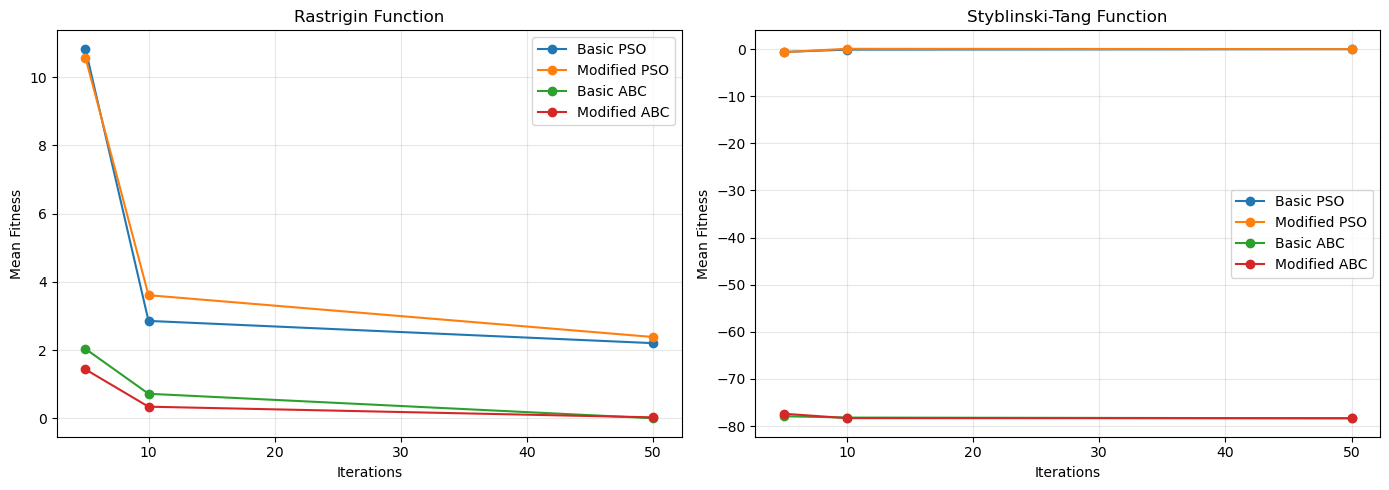

In [ ]:
results_df = run_comparison(num_runs=5, iterations_list=[5, 10, 50])
display_comparison_table(results_df)
plot_comparison(results_df)

In [ ]:
# Average results for modified ABC algorithm
print("\nModified ABC with Rastrigin function:")
for iters, (solution, fitness) in zip(iterations, abc_rastrigin_results):
    print(f"  Iterations: {iters}, Average Best Solution: {solution}, Average Fitness: {fitness}")
print("\nModified ABC with Styblinski-Tang function:")
for iters, (solution, fitness) in zip(iterations, abc_styblinski_results):
    print(f"  Iterations: {iters}, Average Best Solution: {solution}, Average Fitness: {fitness}")


Modified ABC with Rastrigin function:
  Iterations: 5, Average Best Solution: [2.01013354 1.08277569], Average Fitness: 2.3697648092836943
  Iterations: 10, Average Best Solution: [1.97442446 0.00758744], Average Fitness: 2.0745854432224036
  Iterations: 50, Average Best Solution: [1.00119371 1.00075934], Average Fitness: 0.00039708622390932646

Modified ABC with Styblinski-Tang function:
  Iterations: 5, Average Best Solution: [-2.92069639 -2.71958283], Average Fitness: -77.7776711877359
  Iterations: 10, Average Best Solution: [-2.91109378 -2.88410866], Average Fitness: -78.3248583104193
  Iterations: 50, Average Best Solution: [-2.90350697 -2.90357969], Average Fitness: -78.33233135883432



4.	Comment on the results that you have obtained, e.g. which algorithm is probably better, etc. and whether the modifications you introduced have made the optimization better or worse. Explain why it succeeded or failed. You may need to perform more experiments to justify you answers.

Using the baseline results from the beginning we notice that there has not been much of an improvement with the modifications made.
I am guessing that the modifications are far to simple to have a big impact on the result of the algorithm.